In [1]:
from datasets import load_dataset
import pandas as pd
from IPython.display import display

C:\Users\venkm\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
from itertools import islice
import re
import numpy as np

ds_stream = load_dataset("json", data_files="dataset/aida_dev.json", split="train", streaming=True)

seen = set()
unique_texts = []

for example in ds_stream:
    text = example.get("text", "")
    if text and (text not in seen):
        seen.add(text)
        unique_texts.append(example)
    if len(unique_texts) >= 1000:
        break

df = pd.DataFrame(unique_texts)
df["text"] = df["text"].fillna("")
df["spans"] = df.get("spans", [[]])
df = pd.DataFrame(list(islice(unique_texts, 1000)))
df = df[["text"]].copy()
df["text"] = df["text"].fillna("")

In [26]:
df

,text
0,CRICKET - LEICESTERSHIRE TAKE OVER AT TOP AFTE...
1,CRICKET - ENGLISH COUNTY CHAMPIONSHIP SCORES. ...
2,CRICKET - 1997 ASHES INTINERARY. LONDON 1996-0...
3,SOCCER - SHEARER NAMED AS ENGLAND CAPTAIN. LON...
4,BASKETBALL - INTERNATIONAL TOURNAMENT RESULT. ...
...,...
442,SOCCER - SPANISH FIRST DIVISION SUMMARY. MADRI...
443,SOCCER - BALKAN STRIKE FORCE WIN OLD FIRM GAME...
444,SOCCER - PSV HIT VOLENDAM FOR SIX. AMSTERDAM 1...
445,SOCCER - SPANISH FIRST DIVISION RESULT / STAND...


In [27]:
import matplotlib.pyplot as plt
from collections import Counter

plt.style.use("seaborn-v0_8")

token_pattern = re.compile(r"\b\w+\b")
def average_word_length(text: str) -> float:
    tokens = token_pattern.findall(text.lower())
    return float(np.mean([len(token) for token in tokens])) if tokens else 0.0

def lexical_diversity(text: str) -> float:
    tokens = token_pattern.findall(text.lower())
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()
df["sentence_count"] = df["text"].str.count(r"[.!?]")
df["avg_word_length"] = df["text"].apply(average_word_length)

char_nonzero = df["char_count"].replace(0, np.nan)
sentence_nonzero = df["sentence_count"].replace(0, np.nan)

# Derive additional lexical and punctuation-based features
df["digit_count"] = df["text"].str.count(r"\d")
df["uppercase_count"] = df["text"].str.count(r"[A-Z]")
df["punctuation_count"] = df["text"].str.count(r"[^\w\s]")
df["unique_word_ratio"] = df["text"].apply(lexical_diversity)
df["punctuation_density"] = (df["punctuation_count"] / char_nonzero).fillna(0.0)
df["uppercase_ratio"] = (df["uppercase_count"] / char_nonzero).fillna(0.0)
df["chars_per_sentence"] = (df["char_count"] / sentence_nonzero).fillna(df["char_count"])
df["words_per_sentence"] = (df["word_count"] / sentence_nonzero).fillna(df["word_count"])
df["digit_density"] = (df["digit_count"] / df["word_count"].replace(0, np.nan)).fillna(0.0)

metrics_basic = ["char_count", "word_count", "sentence_count", "avg_word_length"]
metrics_extended = [
    "unique_word_ratio","punctuation_density","uppercase_ratio",
    "chars_per_sentence","words_per_sentence","digit_count","digit_density"
 ]
df_summary = df[metrics_basic].describe().round(2)
df_extended_summary = df[metrics_extended].describe().round(3)
display(df_summary, df_extended_summary)

,char_count,word_count,sentence_count,avg_word_length
count,447.00,447.00,447.0,447.00
mean,1140.09,191.85,13.2,4.55
std,912.24,156.07,20.1,0.57
min,141.00,24.00,1.0,2.12
25%,504.50,81.50,4.0,4.34
50%,881.00,148.00,8.0,4.65
75%,1395.00,242.00,15.0,4.92
max,5702.00,850.00,323.0,5.99


,unique_word_ratio,punctuation_density,uppercase_ratio,chars_per_sentence,words_per_sentence,digit_count,digit_density
count,447.000,447.000,447.000,447.000,447.000,447.000,447.000
mean,0.640,0.042,0.102,160.780,30.169,56.964,0.370
std,0.123,0.025,0.089,243.475,62.861,91.555,0.382
min,0.189,0.005,0.020,8.525,1.542,2.000,0.020
25%,0.558,0.026,0.041,81.088,13.134,16.000,0.099
50%,0.645,0.034,0.070,112.667,18.085,25.000,0.190
75%,0.724,0.051,0.129,141.184,22.854,58.500,0.534
max,0.939,0.140,0.530,2864.000,787.000,1064.000,2.336


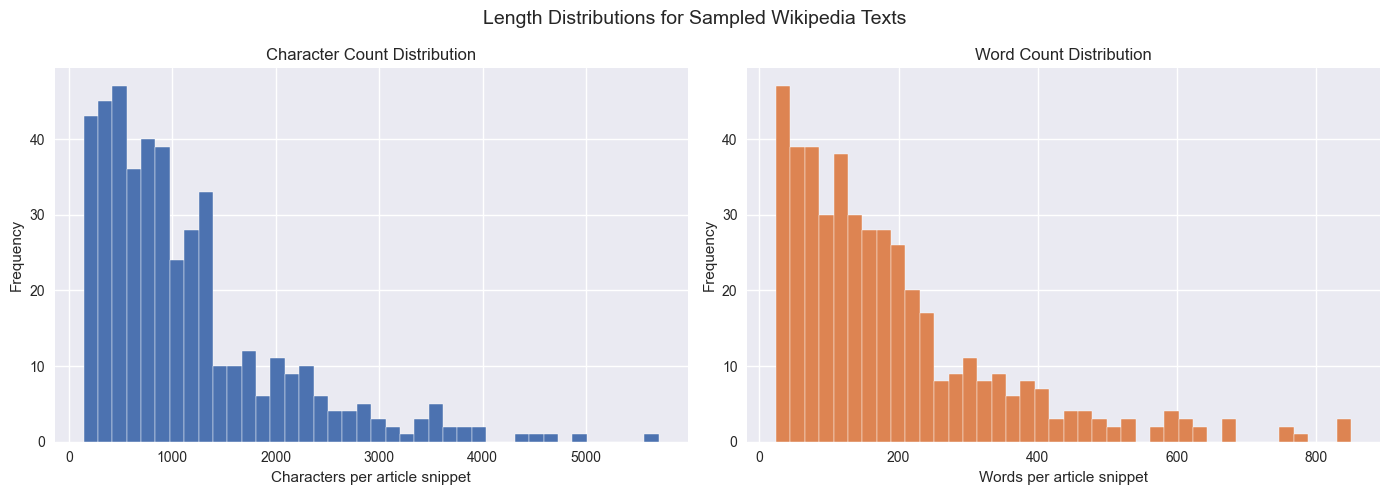

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["char_count"], bins=40, color="#4c72b0", edgecolor="white")
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Characters per article snippet")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["word_count"], bins=40, color="#dd8452", edgecolor="white")
axes[1].set_title("Word Count Distribution")
axes[1].set_xlabel("Words per article snippet")
axes[1].set_ylabel("Frequency")

plt.suptitle("Length Distributions for Sampled Wikipedia Texts", fontsize=14)
plt.tight_layout()
plt.show()

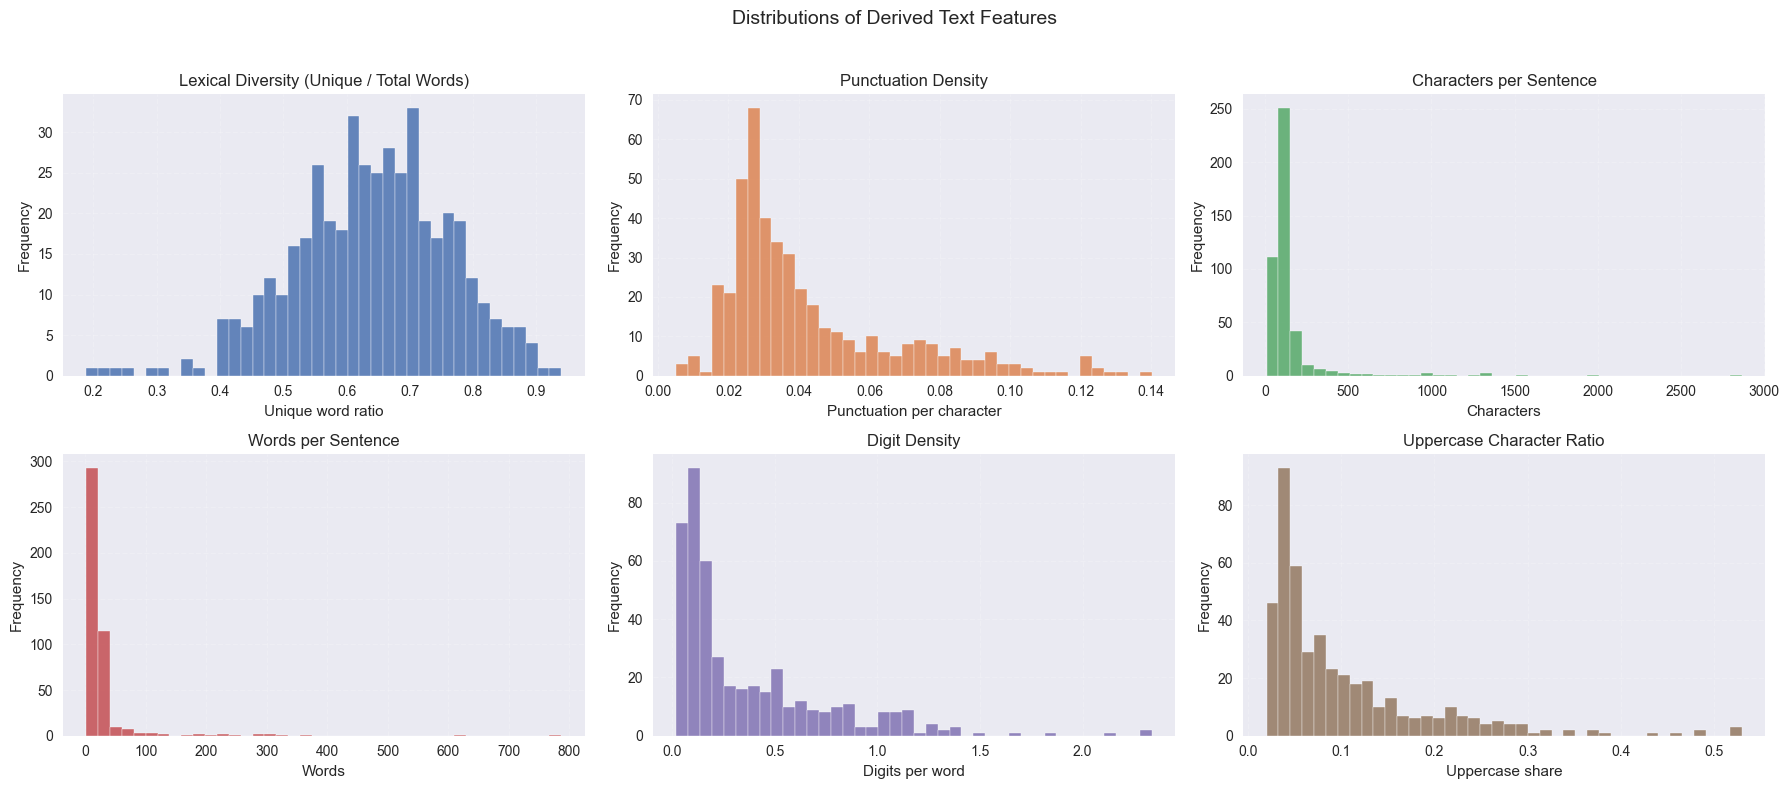

In [29]:
feature_specs = [
    ("unique_word_ratio", "Lexical Diversity (Unique / Total Words)", "Unique word ratio"),
    ("punctuation_density", "Punctuation Density", "Punctuation per character"),
    ("chars_per_sentence", "Characters per Sentence", "Characters"),
    ("words_per_sentence", "Words per Sentence", "Words"),
    ("digit_density", "Digit Density", "Digits per word"),
    ("uppercase_ratio", "Uppercase Character Ratio", "Uppercase share")
]
feature_colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3", "#937860"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (col, title, xlabel), color in zip(axes.flat, feature_specs, feature_colors):
    ax.hist(df[col], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.2)

plt.suptitle("Distributions of Derived Text Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

C:\Users\venkm\AppData\Local\Temp\ipykernel_16148\2108213777.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[col] for col in boxplot_columns], labels=boxplot_columns, showfliers=False, patch_artist=True)


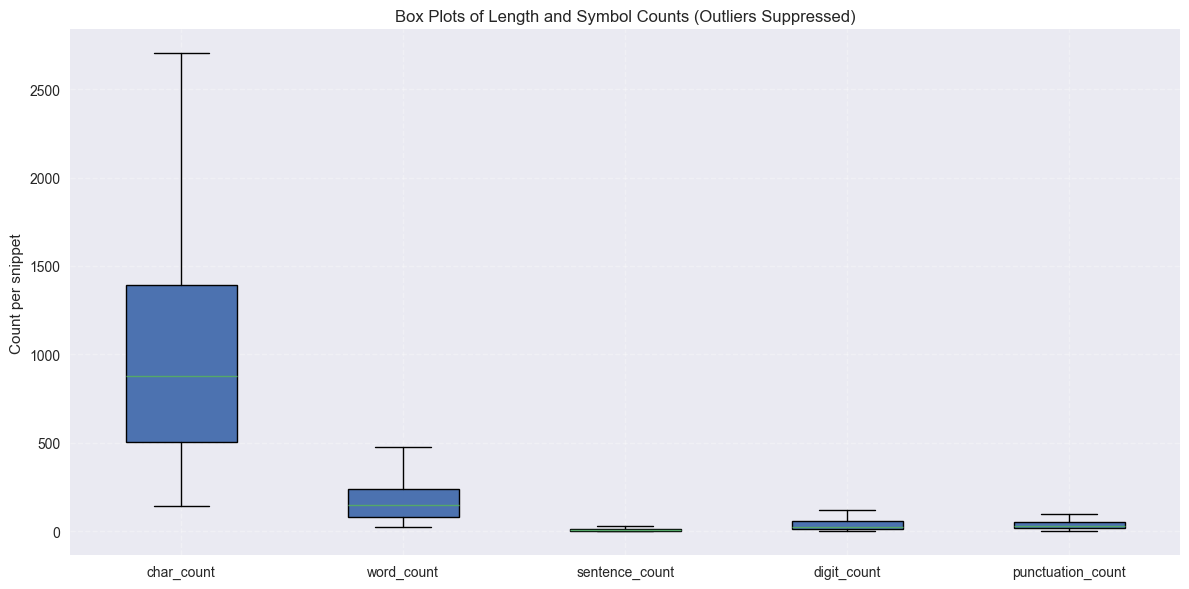

In [30]:
boxplot_columns = ["char_count", "word_count", "sentence_count", "digit_count", "punctuation_count"]
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([df[col] for col in boxplot_columns], labels=boxplot_columns, showfliers=False, patch_artist=True)
for patch, color in zip(ax.artists, ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#937860"]):
    patch.set_facecolor(color)
ax.set_title("Box Plots of Length and Symbol Counts (Outliers Suppressed)")
ax.set_ylabel("Count per snippet")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

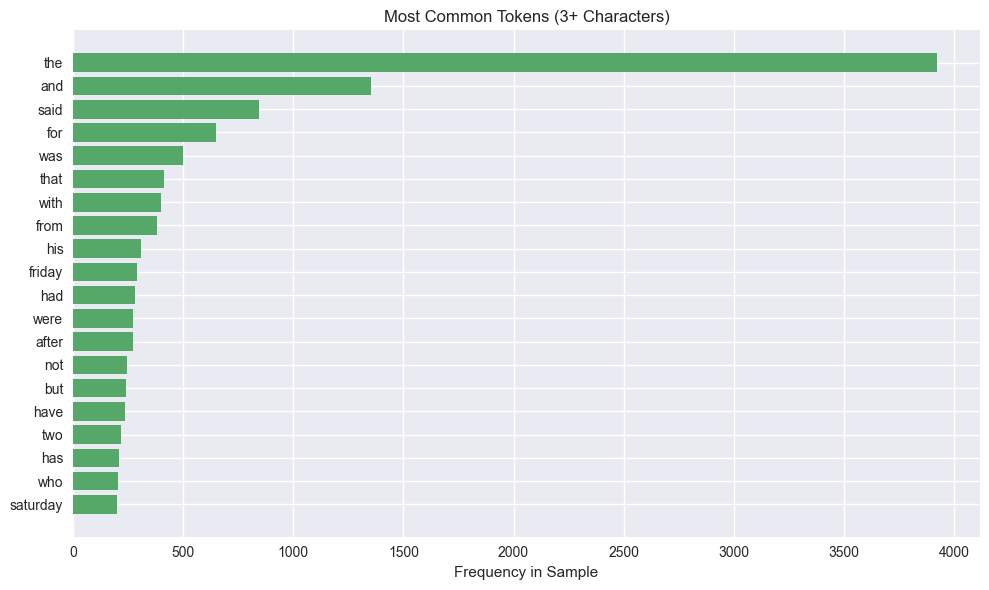

,token,count
0,the,3922
1,and,1352
2,said,845
3,for,647
4,was,498
5,that,415
6,with,400
7,from,379
8,his,308
9,friday,289


In [31]:
freq_pattern = re.compile(r"\b[a-z]{3,}\b")
token_counts = Counter()
for text in df["text"]:
    token_counts.update(freq_pattern.findall(text.lower()))

top_tokens = token_counts.most_common(20)
top_tokens_df = pd.DataFrame(top_tokens, columns=["token", "count"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_tokens_df["token"][::-1], top_tokens_df["count"][::-1], color="#55a868")
ax.set_title("Most Common Tokens (3+ Characters)")
ax.set_xlabel("Frequency in Sample")
plt.tight_layout()
plt.show()

top_tokens_df

In [33]:
avg_char_count = df_summary.loc["mean", "char_count"]
median_word_count = df_summary.loc["50%", "word_count"]
avg_word_length = df_summary.loc["mean", "avg_word_length"]
sentences_per_snippet = df_summary.loc["mean", "sentence_count"]
lexical_diversity = df_extended_summary.loc["mean", "unique_word_ratio"]
punctuation_density = df_extended_summary.loc["mean", "punctuation_density"]
chars_per_sentence = df_extended_summary.loc["mean", "chars_per_sentence"]
words_per_sentence = df_extended_summary.loc["mean", "words_per_sentence"]
digit_density = df_extended_summary.loc["mean", "digit_density"]
uppercase_ratio = df_extended_summary.loc["mean", "uppercase_ratio"]
median_digit_count = df_extended_summary.loc["50%", "digit_count"]
top_tokens_preview = ", ".join(token for token, _ in top_tokens[:5])

print(f"Average snippet length: {avg_char_count:.0f} characters")
print(f"Median snippet length: {median_word_count:.0f} words")
print(f"Mean word length: {avg_word_length:.2f} characters")
print(f"Mean sentences per snippet: {sentences_per_snippet:.2f}")
print(f"Mean lexical diversity: {lexical_diversity:.2f} unique/total words")
print(f"Average punctuation density: {punctuation_density:.2f} per character")
print(f"Mean chars per sentence: {chars_per_sentence:.0f}; words per sentence: {words_per_sentence:.1f}")
print(f"Digit density: {digit_density:.2f} numeric tokens per word (median count {median_digit_count:.0f})")
print(f"Uppercase ratio: {uppercase_ratio:.2f} of characters")
print(f"Frequent content words: {top_tokens_preview}")

Average snippet length: 1140 characters
Median snippet length: 148 words
Mean word length: 4.55 characters
Mean sentences per snippet: 13.20
Mean lexical diversity: 0.64 unique/total words
Average punctuation density: 0.04 per character
Mean chars per sentence: 161; words per sentence: 30.2
Digit density: 0.37 numeric tokens per word (median count 25)
Uppercase ratio: 0.10 of characters
Frequent content words: the, and, said, for, was


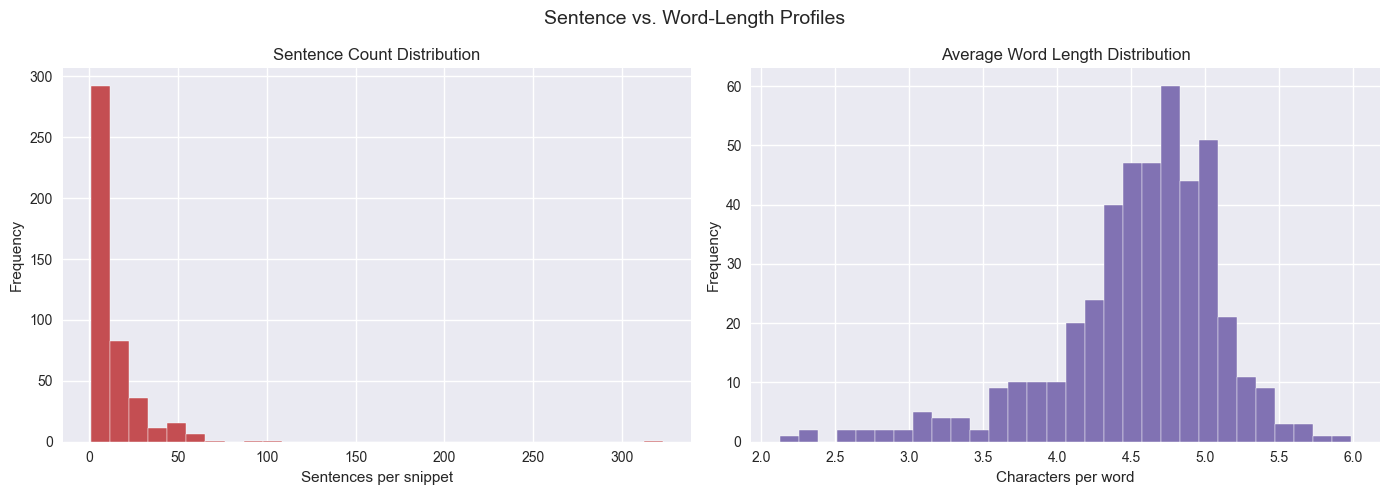

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df["sentence_count"], bins=30, color="#c44e52", edgecolor="white")
axes[0].set_title("Sentence Count Distribution")
axes[0].set_xlabel("Sentences per snippet")
axes[0].set_ylabel("Frequency")

axes[1].hist(df["avg_word_length"], bins=30, color="#8172b3", edgecolor="white")
axes[1].set_title("Average Word Length Distribution")
axes[1].set_xlabel("Characters per word")
axes[1].set_ylabel("Frequency")

plt.suptitle("Sentence vs. Word-Length Profiles", fontsize=14)
plt.tight_layout()
plt.show()

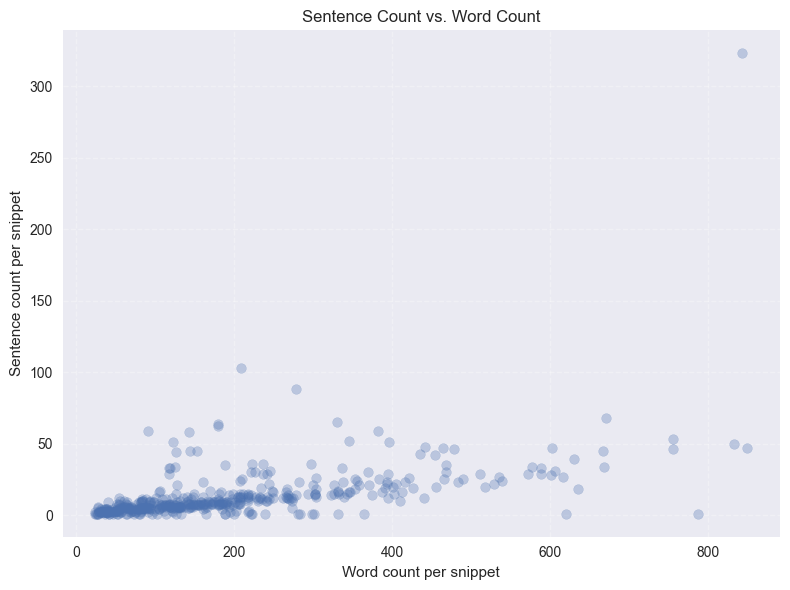

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["word_count"], df["sentence_count"], alpha=0.3, color="#4c72b0")
ax.set_title("Sentence Count vs. Word Count")
ax.set_xlabel("Word count per snippet")
ax.set_ylabel("Sentence count per snippet")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

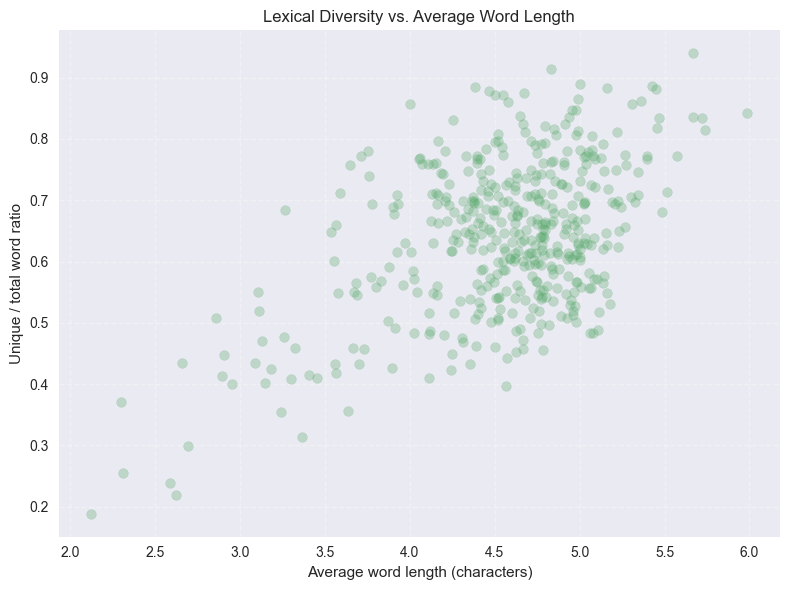

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["avg_word_length"], df["unique_word_ratio"], alpha=0.3, color="#55a868")
ax.set_title("Lexical Diversity vs. Average Word Length")
ax.set_xlabel("Average word length (characters)")
ax.set_ylabel("Unique / total word ratio")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

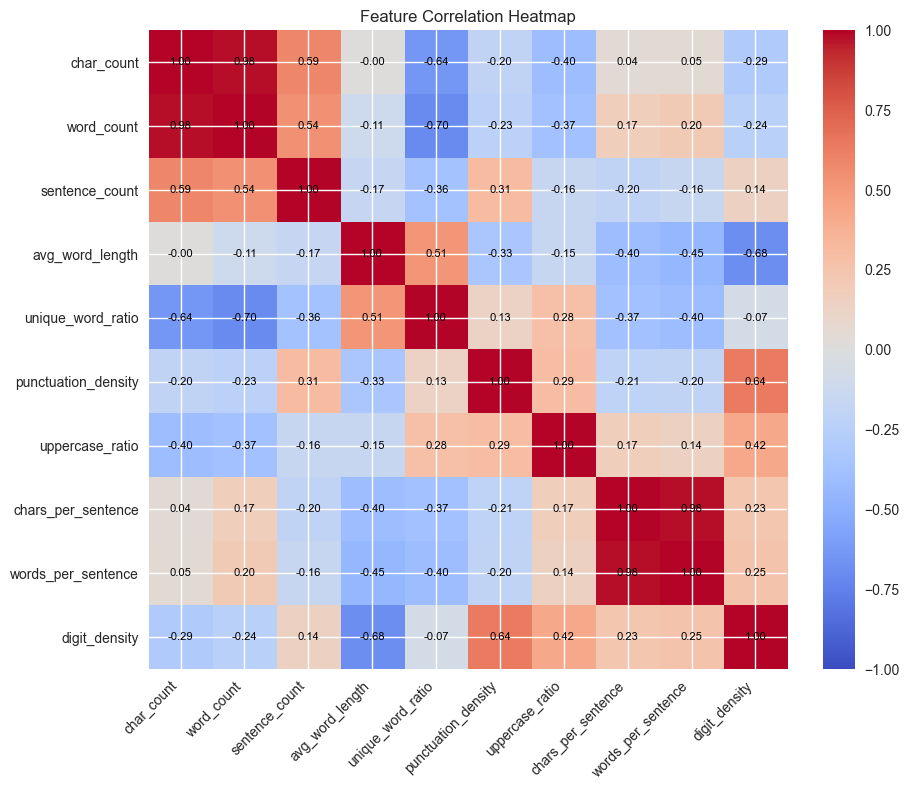

,char_count,word_count,sentence_count,avg_word_length,unique_word_ratio,punctuation_density,uppercase_ratio,chars_per_sentence,words_per_sentence,digit_density
char_count,1.00,0.98,0.59,-0.00,-0.64,-0.20,-0.40,0.04,0.05,-0.29
word_count,0.98,1.00,0.54,-0.11,-0.70,-0.23,-0.37,0.17,0.20,-0.24
sentence_count,0.59,0.54,1.00,-0.17,-0.36,0.31,-0.16,-0.20,-0.16,0.14
avg_word_length,-0.00,-0.11,-0.17,1.00,0.51,-0.33,-0.15,-0.40,-0.45,-0.68
unique_word_ratio,-0.64,-0.70,-0.36,0.51,1.00,0.13,0.28,-0.37,-0.40,-0.07
punctuation_density,-0.20,-0.23,0.31,-0.33,0.13,1.00,0.29,-0.21,-0.20,0.64
uppercase_ratio,-0.40,-0.37,-0.16,-0.15,0.28,0.29,1.00,0.17,0.14,0.42
chars_per_sentence,0.04,0.17,-0.20,-0.40,-0.37,-0.21,0.17,1.00,0.98,0.23
words_per_sentence,0.05,0.20,-0.16,-0.45,-0.40,-0.20,0.14,0.98,1.00,0.25
digit_density,-0.29,-0.24,0.14,-0.68,-0.07,0.64,0.42,0.23,0.25,1.00


In [37]:
corr_columns = [
    "char_count","word_count","sentence_count","avg_word_length",
    "unique_word_ratio","punctuation_density","uppercase_ratio",
    "chars_per_sentence","words_per_sentence","digit_density"
]
corr_matrix = df[corr_columns].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr_columns)))
ax.set_yticklabels(corr_columns)

for (i, j), value in np.ndenumerate(corr_matrix.values):
    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=8)

ax.set_title("Feature Correlation Heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr_matrix

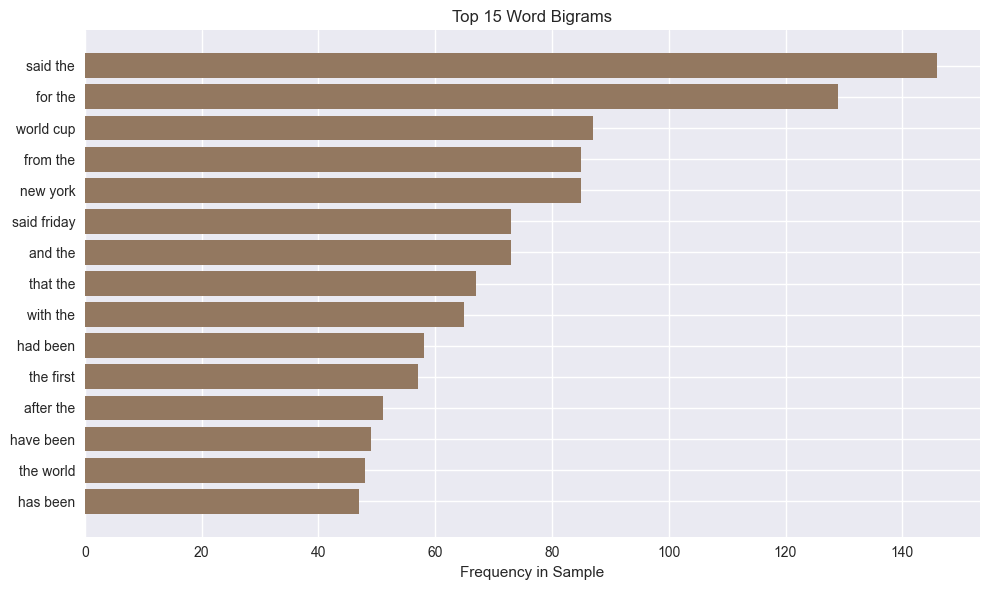

,bigram,count
0,said the,146
1,for the,129
2,world cup,87
3,from the,85
4,new york,85
5,said friday,73
6,and the,73
7,that the,67
8,with the,65
9,had been,58


In [38]:
bigram_counts = Counter()
for text in df["text"]:
    tokens = freq_pattern.findall(text.lower())
    bigram_counts.update(zip(tokens, tokens[1:]))
top_bigrams = bigram_counts.most_common(15)
top_bigrams_df = pd.DataFrame(
    {
        "bigram": [" ".join(bigram) for bigram, _ in top_bigrams],
        "count": [count for _, count in top_bigrams]
    }
 )
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_bigrams_df["bigram"][::-1], top_bigrams_df["count"][::-1], color="#937860")
ax.set_title("Top 15 Word Bigrams")
ax.set_xlabel("Frequency in Sample")
plt.tight_layout()
plt.show()

top_bigrams_df

### Exploratory Observations
- Cell 4 provides paired basic and extended summaries—scan the mean vs. median gaps to understand skew in counts and lexical ratios.
- Cells 5 and 6 chart raw length vs. derived feature distributions, highlighting long tails, punctuation-heavy snippets, and uppercase-heavy articles.
- Cell 7’s box plots make dispersion and potential outliers obvious across length and symbol counts without distraction from extreme values.
- Cells 8 and 14 cover token-level structure: unigram vs. bigram bars expose topical vocabulary and collocations in the slice.
- Cells 10 through 13 capture structural relationships—compare scatterplots with the heatmap to confirm linear trends and spot anomalies.